# **PHASE I: IMAGE PREPROCESSING**
## **Title**:*Automated Blood Cell Image Enhancement and Classification Using Hybrid Spatial–Frequency Domain Processing a*nd Machine Learning*

# **Abstract**
This project focuses on automated blood cell image preprocessing as a foundational step
for medical image classification. The main objective is to enhance image quality using
spatial and frequency domain techniques to improve feature extraction performance later.

The preprocessing pipeline includes resizing, noise removal, contrast enhancement,
histogram equalization, normalization, and frequency domain filtering using Fourier Transform.
These steps improve image clarity, reduce noise, and enhance structural details of blood cells.

The final output is a set of enhanced images ready for machine learning-based classification.

# **PROBLEM DEFINITION:**
Medical blood cell images often contain noise, low contrast, and inconsistencies
that reduce classification accuracy in machine learning models.
# **OBJECTIVES:**
1. Enhance blood cell image quality using image processing techniques.
2. Remove noise and improve contrast.
3. Apply both spatial and frequency domain filtering.
4. Prepare optimized images for feature extraction and classification.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import kagglehub
from scipy.fft import fft2, ifft2, fftshift, ifftshift

# **DATASET DOWNLOAD**




In [ ]:
# Download dataset
path = kagglehub.dataset_download("unclesamulus/blood-cells-image-dataset")

print("Dataset path:", path)

100%|██████████| 268M/268M [00:02<00:00, 139MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/unclesamulus/blood-cells-image-dataset/versions/2


# **FIND DATASET ROOT + CLASSES**

In [ ]:
def find_root(base):
    image_exts = ('.jpg', '.jpeg', '.png')

    for root, dirs, files in os.walk(base):
        valid = 0
        for d in dirs:
            folder = os.path.join(root, d)
            if os.path.isdir(folder):
                imgs = [f for f in os.listdir(folder) if f.endswith(image_exts)]
                if len(imgs) > 10:
                    valid += 1
        if valid >= 2:
            return root
    return base

DATASET_ROOT = find_root(path)

CLASS_NAMES = sorted([
    d for d in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, d))
])

print("Dataset Root:", DATASET_ROOT)
print("Classes:", CLASS_NAMES)

Dataset Root: /root/.cache/kagglehub/datasets/unclesamulus/blood-cells-image-dataset/versions/2/bloodcells_dataset
Classes: ['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


# **VISUALIZE DATASET SAMPLES**

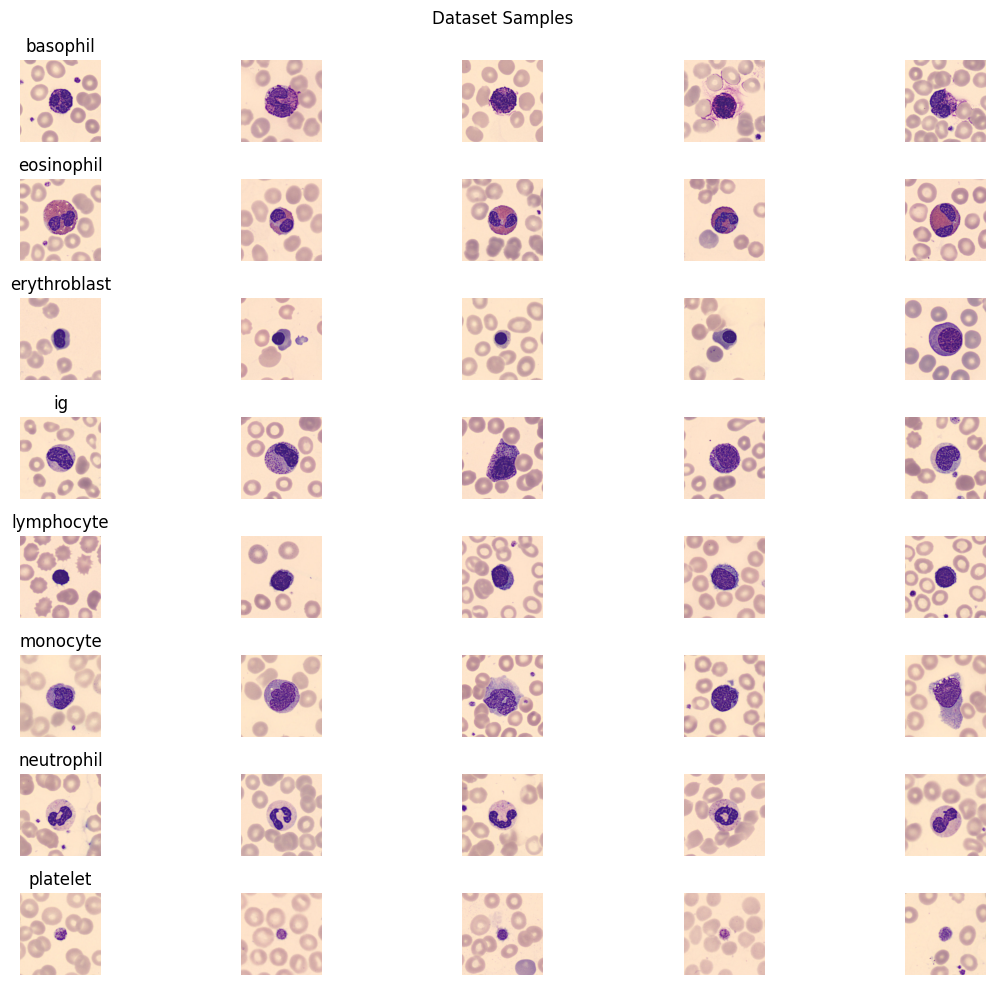

In [ ]:
import random

fig, axes = plt.subplots(len(CLASS_NAMES), 5, figsize=(12, 10))

for i, cls in enumerate(CLASS_NAMES):
    folder = os.path.join(DATASET_ROOT, cls)
    imgs = random.sample(os.listdir(folder), 5)

    for j, img_name in enumerate(imgs):
        img = cv2.imread(os.path.join(folder, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[i, j].imshow(img)
        axes[i, j].axis("off")

        if j == 0:
            axes[i, j].set_title(cls)

plt.suptitle("Dataset Samples")
plt.tight_layout()
plt.show()

# **LOAD SAMPLE IMAGE**

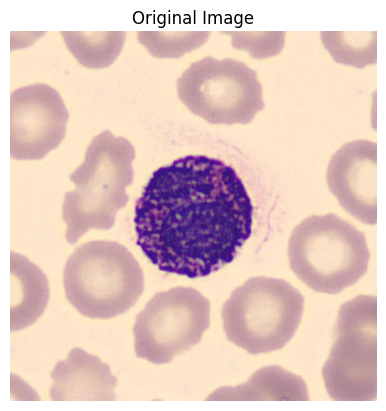

In [ ]:
sample_class = CLASS_NAMES[0]
sample_path = os.path.join(DATASET_ROOT, sample_class)
img_file = os.listdir(sample_path)[0]

img = cv2.imread(os.path.join(sample_path, img_file))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

# **RESIZE + NORMALIZATION**

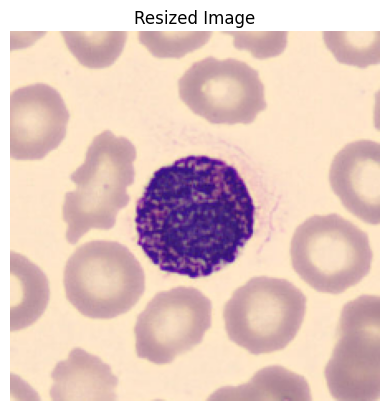

In [ ]:
resized = cv2.resize(img, (224, 224))
normalized = resized / 255.0

plt.imshow(resized)
plt.title("Resized Image")
plt.axis("off")
plt.show()

# **NOISE REMOVAL (GAUSSIAN + MEDIAN + BILATERAL)**

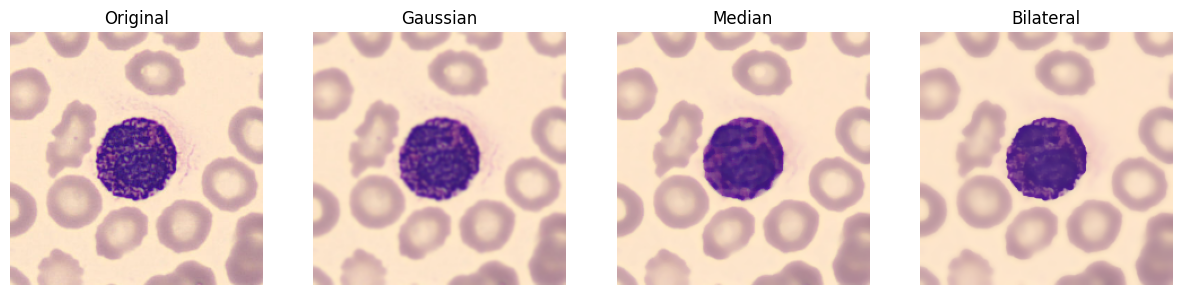

In [ ]:
gaussian = cv2.GaussianBlur(resized, (5,5), 1)
median = cv2.medianBlur(resized, 5)
bilateral = cv2.bilateralFilter(resized, 9, 75, 75)

fig, ax = plt.subplots(1,4, figsize=(15,4))
ax[0].imshow(resized); ax[0].set_title("Original")
ax[1].imshow(gaussian); ax[1].set_title("Gaussian")
ax[2].imshow(median); ax[2].set_title("Median")
ax[3].imshow(bilateral); ax[3].set_title("Bilateral")

for a in ax: a.axis("off")
plt.show()

# **CONTRAST ENHANCEMENT (HIST + CLAHE + GAMMA)**

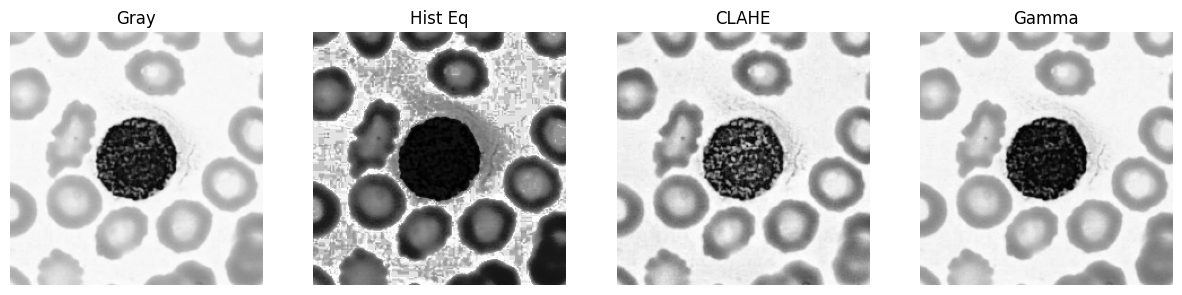

In [ ]:
gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)

# Histogram Equalization
hist_eq = cv2.equalizeHist(gray)

# CLAHE
clahe = cv2.createCLAHE(2.0, (8,8))
clahe_img = clahe.apply(gray)

# Gamma
gamma = 1.5
gamma_img = np.array(255*(gray/255)**gamma, dtype='uint8')

fig, ax = plt.subplots(1,4, figsize=(15,4))
ax[0].imshow(gray, cmap='gray'); ax[0].set_title("Gray")
ax[1].imshow(hist_eq, cmap='gray'); ax[1].set_title("Hist Eq")
ax[2].imshow(clahe_img, cmap='gray'); ax[2].set_title("CLAHE")
ax[3].imshow(gamma_img, cmap='gray'); ax[3].set_title("Gamma")

for a in ax: a.axis("off")
plt.show()

# **EDGE ENHANCEMENT (SHARPEN + SOBEL)**

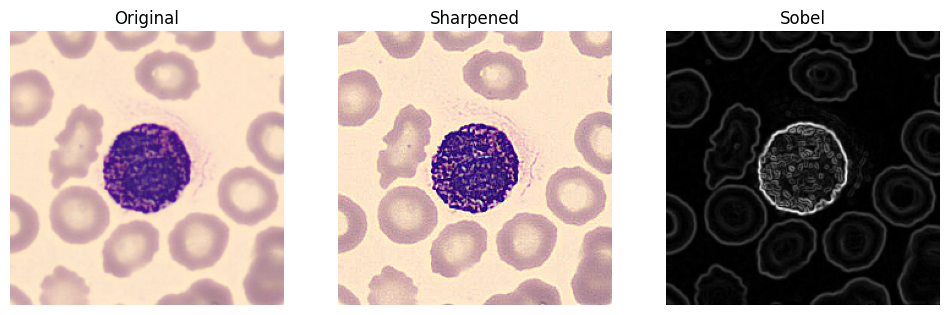

In [ ]:
kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharp = cv2.filter2D(resized, -1, kernel)

sobelx = cv2.Sobel(gray, cv2.CV_64F, 1,0,3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0,1,3)
sobel = cv2.magnitude(sobelx, sobely)

fig, ax = plt.subplots(1,3, figsize=(12,4))
ax[0].imshow(resized); ax[0].set_title("Original")
ax[1].imshow(sharp); ax[1].set_title("Sharpened")
ax[2].imshow(sobel, cmap='gray'); ax[2].set_title("Sobel")

for a in ax: a.axis("off")
plt.show()

# **FREQUENCY DOMAIN FILTERING (LOW + HIGH PASS)**

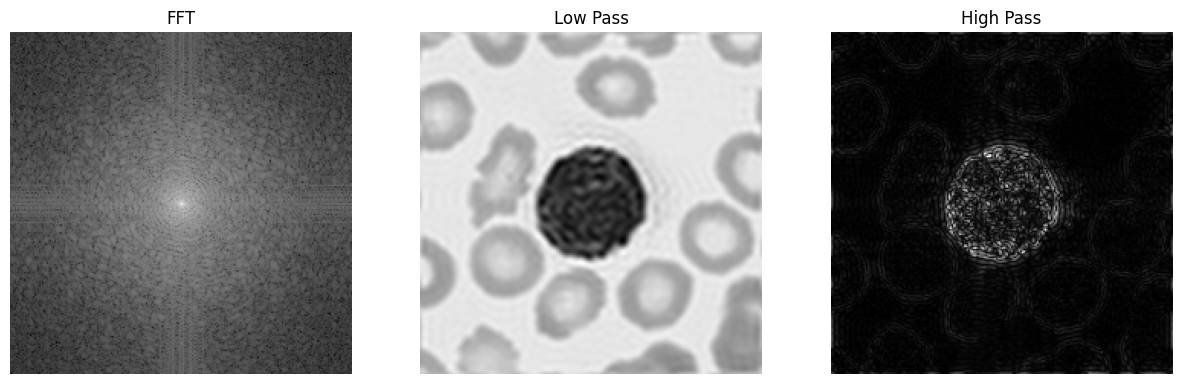

In [ ]:
gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)

f = fft2(gray)
fshift = fftshift(f)

rows, cols = gray.shape
crow, ccol = rows//2, cols//2

# LOW PASS
low_mask = np.zeros((rows, cols))
low_mask[crow-30:crow+30, ccol-30:ccol+30] = 1

# HIGH PASS
high_mask = 1 - low_mask

low = np.abs(ifft2(ifftshift(fshift * low_mask)))
high = np.abs(ifft2(ifftshift(fshift * high_mask)))

fig, ax = plt.subplots(1,3, figsize=(15,5))
ax[0].imshow(np.log(1+np.abs(fshift)), cmap='gray'); ax[0].set_title("FFT")
ax[1].imshow(low, cmap='gray'); ax[1].set_title("Low Pass")
ax[2].imshow(high, cmap='gray'); ax[2].set_title("High Pass")

for a in ax: a.axis("off")
plt.show()

# **FINAL PIPELINE OVERVIEW**

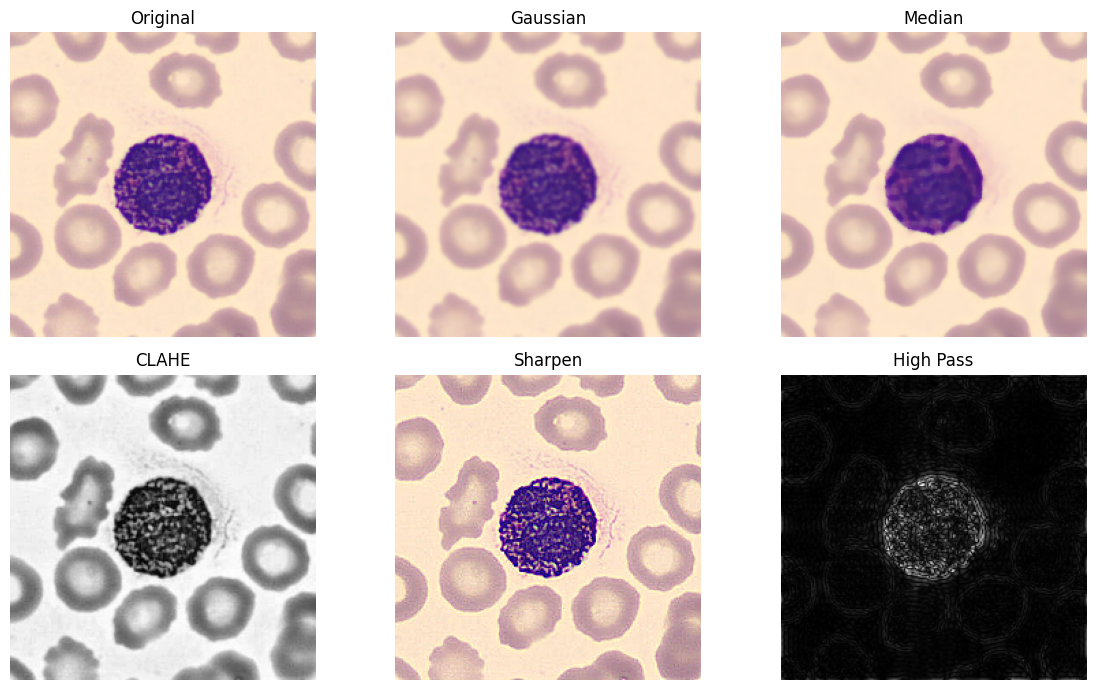

In [ ]:
fig, ax = plt.subplots(2,3, figsize=(12,7))

ax[0,0].imshow(resized); ax[0,0].set_title("Original")
ax[0,1].imshow(gaussian); ax[0,1].set_title("Gaussian")
ax[0,2].imshow(median); ax[0,2].set_title("Median")

ax[1,0].imshow(clahe_img, cmap='gray'); ax[1,0].set_title("CLAHE")
ax[1,1].imshow(sharp); ax[1,1].set_title("Sharpen")
ax[1,2].imshow(high, cmap='gray'); ax[1,2].set_title("High Pass")

for i in range(2):
    for j in range(3):
        ax[i,j].axis("off")

plt.tight_layout()
plt.show()

# **RESULTS & INTERPRETATION **

In [ ]:
print("""
RESULTS:

- Noise successfully reduced using Gaussian, Median, and Bilateral filtering.
- Contrast improved using Histogram Equalization, CLAHE, and Gamma correction.
- Edge structures enhanced using Sobel and sharpening filters.
- Frequency domain filtering improved structural clarity of cells.
- Final images show clearer morphological details for classification.

CONCLUSION:
The preprocessing pipeline significantly enhances blood cell image quality
and prepares data for robust machine learning classification.
""")


RESULTS:

- Noise successfully reduced using Gaussian, Median, and Bilateral filtering.
- Contrast improved using Histogram Equalization, CLAHE, and Gamma correction.
- Edge structures enhanced using Sobel and sharpening filters.
- Frequency domain filtering improved structural clarity of cells.
- Final images show clearer morphological details for classification.

CONCLUSION:
The preprocessing pipeline significantly enhances blood cell image quality
and prepares data for robust machine learning classification.

